In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [2]:
df=pd.read_csv("Salary_dataset.csv")

In [3]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
## drop unnecassary column 
df.drop("Unnamed: 0", axis=1, inplace=True)

Text(0, 0.5, 'Salary')

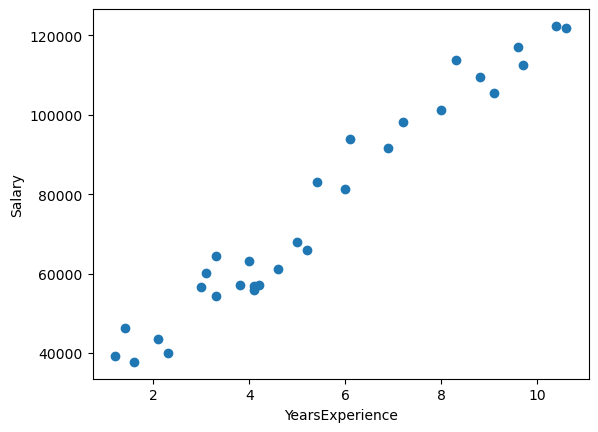

In [5]:
#scatter plot to see data scatter in graphical form 
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel("YearsExperience")
plt.ylabel("Salary")

In [6]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [7]:
#independent and dependent feature 
X=df[["YearsExperience"]]
Y=df["Salary"]

In [8]:
#train test split
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn + transform
X_test = scaler.transform(X_test)         # only transform

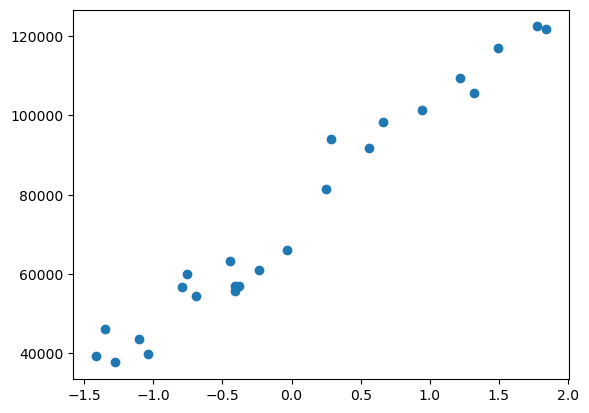

In [12]:
plt.scatter(X_train,Y_train)

In [13]:
## train the Simple Linear Regression Model 
from sklearn.linear_model import LinearRegression

In [14]:
regressor=LinearRegression()

In [15]:
regressor.fit(X_train,Y_train) 
# X input feature and Y output feature corresponding to X

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
print("the slope or coefficient of weight ",regressor.coef_)
print("Intercept: ",regressor.intercept_)

the slope or coefficient of weight  [27151.53742583]
Intercept:  74208.625


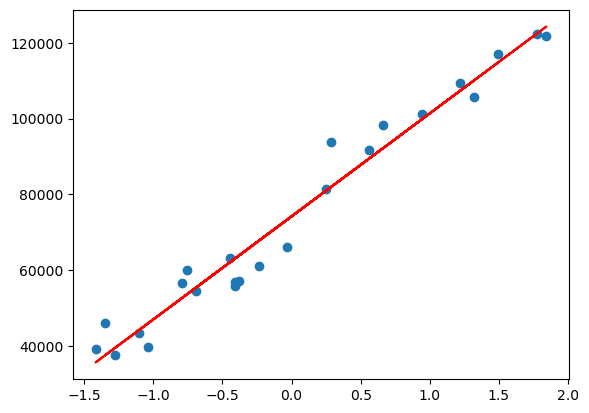

In [17]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

In [18]:
#prediction part on Y_test
Y_pred_test= regressor.predict(X_test)
# this one is for comparison for our actual output 

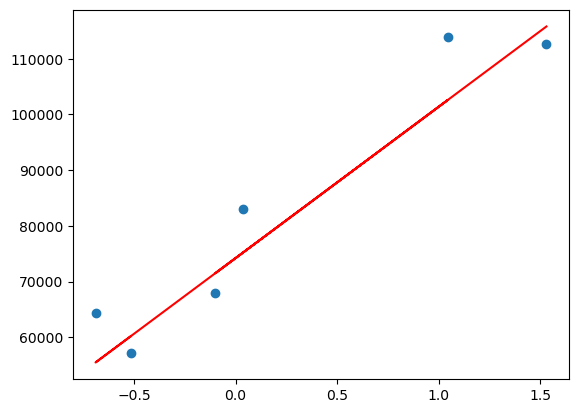

In [19]:
plt.scatter(X_test,Y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

In [21]:
#performance matrix to find accuracy
from sklearn.metrics import r2_score
score=r2_score(Y_test,Y_pred_test)

In [22]:
score

0.9024461774180499

In [23]:
#adjusted r2
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.8780577217725624

In [28]:
##new data point weight is 2.5
new_data = [[5]]

In [29]:
new_data = scaler.transform(new_data)

C:\Users\anshu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [30]:
regressor.predict(new_data)

array([71499.27809463])